In [1]:
import re
import csv
import copy
import math
import json
import traceback
import numpy as np
import pandas as pd
from pathlib import Path
import numpy.linalg as npl
from itertools import product
from scipy.optimize import root
import matplotlib.pyplot as plt
from __future__ import annotations
from scipy.sparse.linalg import eigs
from matplotlib.patches import Circle, Patch
from scipy.sparse import csr_matrix, diags, eye
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dataclasses import dataclass, replace, asdict, is_dataclass
from typing import Any, Dict, Iterable, Iterator, List, Mapping, Optional, Tuple, Sequence

In [2]:
# ============================================================
#  Parameters
# ============================================================

@dataclass(frozen=True)
class AreaParams:
    """
    Parameters for one brain area.

    N      : number of neurons in this area
    s      : local sparsity, defined by C_i / N_i
    f_exc  : fraction of excitatory neurons in this area
    J_exc  : local excitatory synaptic weight in this area
    g_inh  : local inhibitory strength ratio
    """
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    """
    Parameters for the full multi-area network.

    s_cross[src, tgt] : cross-area sparsity from src to tgt
    J_cross[src, tgt] : cross-area excitatory weight from src to tgt

    activation: "tanh" or "threshold_linear"
    phi_max   : only used if activation == "threshold_linear"
    gamma     : threshold offset in phi(x) = max(0, x + gamma)
    """
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray
    J_cross: np.ndarray
    allow_autapses: bool
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float


# ============================================================
#  Activation
# ============================================================

def phi(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        return np.tanh(x) + 1.0

    if p.activation == "threshold_linear":
        y = np.maximum(0.0, x + p.gamma)
        if np.isfinite(p.phi_max):
            y = np.minimum(p.phi_max, y)
        return y

    raise ValueError(f"Unknown activation = {p.activation}")


def phi_prime(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        y = np.tanh(x)
        return 1.0 - y * y

    if p.activation == "threshold_linear":
        g = ((x + p.gamma) >= 0.0).astype(float)
        if np.isfinite(p.phi_max):
            g = g * ((x + p.gamma) < p.phi_max)
        return g

    raise ValueError(f"Unknown activation = {p.activation}")


# ============================================================
#  Population bookkeeping
# ============================================================

def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    pops = []
    pop_sizes = []
    pop_slices = {}
    area_slices = {}
    area_stats = []

    start = 0
    for area_id, ap in enumerate(p.areas):
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E

        if N_E < 0 or N_I < 0:
            raise ValueError(f"Area {area_id}: invalid E/I split")

        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        e_slice = slice(start, start + N_E)
        pops.append((area_id, "E"))
        pop_slices[(area_id, "E")] = e_slice
        pop_sizes.append(N_E)
        start += N_E

        i_slice = slice(start, start + N_I)
        pops.append((area_id, "I"))
        pop_slices[(area_id, "I")] = i_slice
        pop_sizes.append(N_I)
        start += N_I

        area_slices[area_id] = slice(e_slice.start, i_slice.stop)

        area_stats.append(
            {
                "area_id": area_id,
                "N": ap.N,
                "N_E": N_E,
                "N_I": N_I,
                "C": C,
                "C_E": C_E,
                "C_I": C_I,
                "J_E": ap.J_exc,
                "J_I": -ap.g_inh * ap.J_exc,
            }
        )

    return {
        "pops": pops,
        "pop_sizes": np.asarray(pop_sizes, dtype=int),
        "N_total": start,
        "pop_slices": pop_slices,
        "area_slices": area_slices,
        "area_stats": area_stats,
    }


def _validate_params(p: MultiAreaParams) -> None:
    A = len(p.areas)

    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")
    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")

    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def _candidate_pool(indices: np.ndarray, target_idx: int, allow_autapses: bool) -> np.ndarray:
    if allow_autapses or len(indices) == 0:
        return indices

    if indices[0] <= target_idx <= indices[-1]:
        return indices[indices != target_idx]
    return indices

In [3]:
# ============================================================
# basic helpers
# ============================================================

def sanitize_name(name: str) -> str:
    s = re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")
    return s if s else "case"


def metric_label(quantity: str) -> str:
    if quantity == "E_x":
        return r"$E_x(t)=\frac{1}{N}\sum_i (x_i-x_i^{\mathrm{ref}})^2$"
    elif quantity == "E_phi":
        return r"$E_\phi(t)=\frac{1}{N}\sum_i (\phi(x_i)-\phi(x_i^{\mathrm{ref}}))^2$"
    else:
        raise ValueError(f"Unknown quantity: {quantity}")


def reconstruct_params_from_summary(summary: dict) -> MultiAreaParams:
    p_dict = summary["multi_area_params"]

    areas = tuple(
        AreaParams(
            N=area["N"],
            s=area["s"],
            f_exc=area["f_exc"],
            J_exc=area["J_exc"],
            g_inh=area["g_inh"],
        )
        for area in p_dict["areas"]
    )

    p = MultiAreaParams(
        areas=areas,
        s_cross=np.asarray(p_dict["s_cross"], dtype=float),
        J_cross=np.asarray(p_dict["J_cross"], dtype=float),
        allow_autapses=bool(p_dict["allow_autapses"]),
        activation=p_dict["activation"],
        phi_max=float(p_dict["phi_max"]),
        gamma=float(p_dict["gamma"]),
        dt=float(p_dict["dt"]),
        T=float(p_dict["T"]),
    )
    return p


def load_saved_run(
    output_root: str | Path,
    case_name: str,
    perturbation_name: str,
) -> dict:
    """
    Load one saved run:
        output_root / case_name / perturbation_subdir / {timeseries.npz, summary.json}

    We do not assume the perturbation subdir name exactly equals perturbation_name.
    Instead, we inspect summary.json and match by scalar_summary['perturbation_name'].
    """
    case_dir = Path(output_root) / sanitize_name(case_name)
    if not case_dir.exists():
        raise FileNotFoundError(f"Case directory not found: {case_dir}")

    target_dir = None
    target_summary = None

    for subdir in case_dir.iterdir():
        if not subdir.is_dir():
            continue

        summary_path = subdir / "summary.json"
        npz_path = subdir / "timeseries.npz"
        if (not summary_path.exists()) or (not npz_path.exists()):
            continue

        with open(summary_path, "r", encoding="utf-8") as f:
            summary = json.load(f)

        saved_name = summary["scalar_summary"]["perturbation_name"]
        if saved_name == perturbation_name:
            target_dir = subdir
            target_summary = summary
            break

    if target_dir is None:
        raise FileNotFoundError(
            f"Could not find perturbation '{perturbation_name}' under case '{case_name}'"
        )

    npz_path = target_dir / "timeseries.npz"
    with np.load(npz_path) as data:
        run = {key: data[key] for key in data.files}

    run["summary"] = target_summary
    run["run_dir"] = target_dir
    run["case_name"] = case_name
    run["perturbation_name"] = perturbation_name
    run["p"] = reconstruct_params_from_summary(target_summary)

    return run


def load_any_saved_run_for_case(
    output_root: str | Path,
    case_name: str,
    preferred_perturbation_name: str = "mean perturbation",
) -> dict:
    """
    For relaxation plotting, pre-history is identical across perturbations within one case.
    So we can load any one saved perturbation under this case.
    Prefer mean perturbation if available.
    """
    case_dir = Path(output_root) / sanitize_name(case_name)
    if not case_dir.exists():
        raise FileNotFoundError(f"Case directory not found: {case_dir}")

    # try preferred
    try:
        return load_saved_run(output_root, case_name, preferred_perturbation_name)
    except FileNotFoundError:
        pass

    # fallback: first valid subdir
    for subdir in case_dir.iterdir():
        if not subdir.is_dir():
            continue
        summary_path = subdir / "summary.json"
        npz_path = subdir / "timeseries.npz"
        if summary_path.exists() and npz_path.exists():
            with open(summary_path, "r", encoding="utf-8") as f:
                summary = json.load(f)
            pname = summary["scalar_summary"]["perturbation_name"]
            return load_saved_run(output_root, case_name, pname)

    raise FileNotFoundError(f"No saved perturbation run found under case '{case_name}'")


# ============================================================
# metric extraction
# ============================================================

def compute_post_t0_statistics(run: dict) -> dict:
    """
    Reconstruct the immediate post-perturbation state at t=0:
        x_post0 = x_end + perturbation

    This is useful because the merged saved time series may only keep the pre-side t=0 point.
    """
    p = run["p"]
    info = population_info(p)

    x_ref = np.asarray(run["x_ref"], dtype=float)
    x_end = np.asarray(run["x_end"], dtype=float)
    perturbation = np.asarray(run["perturbation"], dtype=float)

    x_post0 = x_end + perturbation

    dx = x_post0 - x_ref
    phi_ref = np.asarray(phi(x_ref, p), dtype=float)
    dphi = np.asarray(phi(x_post0, p), dtype=float) - phi_ref

    E_x_total = float(np.mean(dx ** 2))
    E_phi_total = float(np.mean(dphi ** 2))

    n_areas = len(p.areas)
    E_x_by_area = np.empty(n_areas, dtype=float)
    E_phi_by_area = np.empty(n_areas, dtype=float)

    for area_id in range(n_areas):
        sl = info["area_slices"][area_id]
        E_x_by_area[area_id] = float(np.mean(dx[sl] ** 2))
        E_phi_by_area[area_id] = float(np.mean(dphi[sl] ** 2))

    return {
        "E_x_total": E_x_total,
        "E_phi_total": E_phi_total,
        "E_x_by_area": E_x_by_area,
        "E_phi_by_area": E_phi_by_area,
    }


def get_metric_array(run: dict, quantity: str, area_id: Optional[int] = None) -> np.ndarray:
    if quantity == "E_x":
        arr = run["E_x_total"] if area_id is None else run["E_x_by_area"][:, area_id]
    elif quantity == "E_phi":
        arr = run["E_phi_total"] if area_id is None else run["E_phi_by_area"][:, area_id]
    else:
        raise ValueError(f"Unknown quantity: {quantity}")
    return np.asarray(arr, dtype=float)


def extract_relaxation_curve(
    run: dict,
    quantity: str,
    area_id: Optional[int] = None,
) -> tuple[np.ndarray, np.ndarray]:
    mask_pre = (run["is_post_perturbation"] == 0)
    t = np.asarray(run["t"][mask_pre], dtype=float)
    y = get_metric_array(run, quantity, area_id=area_id)[mask_pre]
    return t, y


def extract_response_curve(
    run: dict,
    quantity: str,
    area_id: Optional[int] = None,
    include_post_t0: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract post-perturbation response curve.

    If include_post_t0=True, prepend the reconstructed immediate post-perturbation point at t=0.
    """
    mask_post = (run["is_post_perturbation"] == 1)
    t_post = np.asarray(run["t"][mask_post], dtype=float)
    y_post = get_metric_array(run, quantity, area_id=area_id)[mask_post]

    if not include_post_t0:
        return t_post, y_post

    stats0 = compute_post_t0_statistics(run)
    if quantity == "E_x":
        y0 = stats0["E_x_total"] if area_id is None else stats0["E_x_by_area"][area_id]
    elif quantity == "E_phi":
        y0 = stats0["E_phi_total"] if area_id is None else stats0["E_phi_by_area"][area_id]
    else:
        raise ValueError(f"Unknown quantity: {quantity}")

    if t_post.size == 0:
        return np.array([0.0], dtype=float), np.array([y0], dtype=float)

    if np.isclose(t_post[0], 0.0):
        return t_post, y_post

    t = np.concatenate([[0.0], t_post])
    y = np.concatenate([[y0], y_post])
    return t, y


# ============================================================
# plotting helpers
# ============================================================

def create_energy_axes(
    n_areas: int,
    max_cols: int = 3,
    col_width: float = 4.2,
    row_height: float = 3.2,
):
    """
    panel 0: whole network
    panel 1...: area-wise
    """
    n_panels = n_areas + 1
    ncols = min(max_cols, n_panels)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(col_width * ncols, row_height * nrows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for j in range(n_panels, nrows * ncols):
        axes[j].axis("off")

    return fig, axes


def plot_curve(
    ax,
    t: np.ndarray,
    y: np.ndarray,
    label: str,
    logy: bool = True,
    linewidth: float = 2.0,
    alpha: float = 1.0,
    linestyle: str = "-",
):
    if logy:
        # avoid log(0)
        y_plot = np.maximum(np.asarray(y, dtype=float), 1e-16)
        ax.semilogy(t, y_plot, label=label, linewidth=linewidth, alpha=alpha, linestyle=linestyle)
    else:
        ax.plot(t, y, label=label, linewidth=linewidth, alpha=alpha, linestyle=linestyle)


def finalize_axis(
    ax,
    title: str,
    ylabel: str,
    show_zero_line: bool = True,
    xlabel: str = "t",
):
    if show_zero_line:
        ax.axvline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ============================================================
# multi-trial loader and one-shot multi-trial plot helper
# ============================================================

# Seconds to draw after the perturbation. Use None to draw the full post-perturbation range.
POST_WINDOW = 30.0


def load_all_trials(
    output_root: str | Path,
    case_name: str,
    perturbation_name: str,
) -> List[dict]:
    """
    Load every trial_XXX subdir under
        output_root / case_name / <perturbation_subdir>
    where the perturbation subdir is matched by
        summary.json -> scalar_summary["perturbation_name"] == perturbation_name.
    Returns a list of run dicts (same schema as load_saved_run), sorted by
    trial_idx ascending.
    """
    case_dir = Path(output_root) / sanitize_name(case_name)
    if not case_dir.exists():
        raise FileNotFoundError(f"Case directory not found: {case_dir}")

    perturb_dir = None
    for subdir in case_dir.iterdir():
        if not subdir.is_dir():
            continue
        trial_dirs = sorted(d for d in subdir.iterdir() if d.is_dir() and d.name.startswith("trial_"))
        if not trial_dirs:
            continue
        first_summary = trial_dirs[0] / "summary.json"
        if not first_summary.exists():
            continue
        with open(first_summary, "r", encoding="utf-8") as f:
            summary0 = json.load(f)
        if summary0["scalar_summary"]["perturbation_name"] == perturbation_name:
            perturb_dir = subdir
            break

    if perturb_dir is None:
        raise FileNotFoundError(
            f"Could not find perturbation '{perturbation_name}' under case '{case_name}'"
        )

    trials = []
    for trial_dir in sorted(perturb_dir.iterdir()):
        if not trial_dir.is_dir() or not trial_dir.name.startswith("trial_"):
            continue
        summary_path = trial_dir / "summary.json"
        npz_path = trial_dir / "timeseries.npz"
        if not (summary_path.exists() and npz_path.exists()):
            continue

        with open(summary_path, "r", encoding="utf-8") as f:
            summary = json.load(f)
        with np.load(npz_path) as data:
            run = {key: data[key] for key in data.files}

        run["summary"] = summary
        run["run_dir"] = trial_dir
        run["case_name"] = case_name
        run["perturbation_name"] = perturbation_name
        run["p"] = reconstruct_params_from_summary(summary)
        run["trial_idx"] = int(summary["scalar_summary"].get("trial_idx", 0))
        trials.append(run)

    if not trials:
        raise FileNotFoundError(f"No trial_XXX subdirs found under {perturb_dir}")

    trials.sort(key=lambda r: r["trial_idx"])
    return trials


def plot_multitrial(
    ax,
    runs: List[dict],
    quantity: str,
    area_id: Optional[int],
    kind: str,
    color,
    label: Optional[str] = None,
    logy: bool = True,
    n_grid: int = 400,
    linewidth: float = 2.0,
    linestyle: str = "-",
    band_alpha: float = 0.2,
    pre_window: float = 10.0,
    post_window: Optional[float] = POST_WINDOW,
):
    """
    Drop-in replacement for plot_curve when you have multiple trials.

    kind == "relaxation"  ->  pre-perturbation (t < 0). Each trial's pre
                              curve is interpolated onto a shared window
                              [t_start_common, 0], then averaged.
    kind == "response"    ->  post-perturbation (t >= 0). If post_window is
                              not None, only [0, post_window] is shown.
                              Curves are stacked directly (post grid is shared by construction
                              given fixed dt / store_every / response_T;
                              we still interpolate as a safety net).

    On a log y-axis the band is geometric:
        mu = exp(mean(log y))
        lo = exp(mean(log y) - std(log y))
        hi = exp(mean(log y) + std(log y))
    On a linear axis it is mu +/- std (lower bound clipped to 1e-16).
    """
    # ---- (1) build (t, y_stack) of shape (n_trials, T) ----
    if kind == "relaxation":
        pre_curves = [extract_relaxation_curve(r, quantity, area_id=area_id) for r in runs]
        t_start_common = max(t[0] for t, _ in pre_curves if t.size > 0)
        # clamp to the last `pre_window` seconds before perturbation onset.
        # rationale: relaxations have variable duration (tolerance-based stop);
        # by only showing the tail before t=0, every case/trial has the same
        # plotted t-window and the curves visually share the same converged
        # baseline before the perturbation lands.
        t_start_common = max(t_start_common, -float(pre_window))
        t_end = 0.0
        if t_start_common >= t_end:
            t_start_common = t_end - 1e-9
        t = np.linspace(t_start_common, t_end, n_grid)
        y_stack = np.stack([np.interp(t, tt, yy) for tt, yy in pre_curves])

    elif kind == "response":
        t0, y0 = extract_response_curve(runs[0], quantity, area_id=area_id, include_post_t0=True)
        t = t0
        if post_window is not None:
            post_window = float(post_window)
            if post_window < 0.0:
                raise ValueError("post_window must be non-negative or None")
            keep = t <= post_window
            if not np.any(keep):
                keep = np.isclose(t, 0.0)
            t = t[keep]
            y0 = y0[keep]
        y_stack = np.empty((len(runs), t.shape[0]), dtype=float)
        y_stack[0] = y0
        for k, r in enumerate(runs[1:], start=1):
            tk, yk = extract_response_curve(r, quantity, area_id=area_id, include_post_t0=True)
            if tk.shape == t.shape and np.allclose(tk, t):
                y_stack[k] = yk
            else:
                y_stack[k] = np.interp(t, tk, yk)

    else:
        raise ValueError(f"Unknown kind: {kind} (expected 'relaxation' or 'response')")

    # ---- (2) reduce to mean + band ----
    if logy:
        ly = np.log(np.maximum(y_stack, 1e-300))
        mu_log = np.mean(ly, axis=0)
        sd_log = np.std(ly, axis=0)
        mu = np.exp(mu_log)
        lo = np.exp(mu_log - sd_log)
        hi = np.exp(mu_log + sd_log)
    else:
        mu = np.mean(y_stack, axis=0)
        sd = np.std(y_stack, axis=0)
        lo = np.maximum(mu - sd, 1e-16)
        hi = mu + sd

    # ---- (3) draw mean line + same-color shaded band ----
    if logy:
        ax.semilogy(
            t, np.maximum(mu, 1e-16),
            color=color, linewidth=linewidth, linestyle=linestyle, label=label,
        )
        ax.fill_between(
            t, np.maximum(lo, 1e-16), hi,
            color=color, alpha=band_alpha, linewidth=0,
        )
    else:
        ax.plot(t, mu, color=color, linewidth=linewidth, linestyle=linestyle, label=label)
        ax.fill_between(t, lo, hi, color=color, alpha=band_alpha, linewidth=0)


# ============================================================
# figure 1: single case, compare two perturbations
#   (now averaged over n_trials per (case, perturbation) and
#    drawn with a same-color uncertainty band)
# ============================================================

def plot_single_case_comparison(
    output_root: str | Path,
    case_name: str,
    quantity: str = "E_x",
    mean_name: str = "mean perturbation",
    gaussian_name: str = "Gaussian perturbation",
    logy: bool = True,
    max_cols: int = 3,
    col_width: float = 4.2,
    row_height: float = 3.2,
    pre_window: float = 10.0,
    post_window: Optional[float] = POST_WINDOW,
):
    """
    For one case:
      - relaxation (t < 0)
      - mean perturbation response (t >= 0)
      - Gaussian perturbation response (t >= 0)

    Each curve is the trial-averaged mean with a same-color shaded band.
    """
    # run_mean = load_saved_run(output_root, case_name, mean_name)         # original
    # run_gauss = load_saved_run(output_root, case_name, gaussian_name)    # original
    runs_mean = load_all_trials(output_root, case_name, mean_name)
    runs_gauss = load_all_trials(output_root, case_name, gaussian_name)

    A = runs_mean[0]["E_x_by_area"].shape[1]
    fig, axes = create_energy_axes(
        n_areas=A,
        max_cols=max_cols,
        col_width=col_width,
        row_height=row_height,
    )

    ylabel = metric_label(quantity)

    # whole network
    ax = axes[0]
    # plot_curve(ax, t_pre,   y_pre,   label="relaxation",  ...)   # original
    # plot_curve(ax, t_mean,  y_mean,  label=mean_name,     ...)   # original
    # plot_curve(ax, t_gauss, y_gauss, label=gaussian_name, ...)   # original
    plot_multitrial(ax, runs_mean,  quantity, None, "relaxation", color="C0", label="relaxation",  logy=logy, pre_window=pre_window)
    plot_multitrial(ax, runs_mean,  quantity, None, "response",   color="C1", label=mean_name,     logy=logy, post_window=post_window)
    plot_multitrial(ax, runs_gauss, quantity, None, "response",   color="C2", label=gaussian_name, logy=logy, post_window=post_window)
    finalize_axis(ax, title="Whole network", ylabel=ylabel, show_zero_line=True)
    ax.legend(fontsize=9)

    # per-area panels
    for area_id in range(A):
        ax = axes[area_id + 1]
        plot_multitrial(ax, runs_mean,  quantity, area_id, "relaxation", color="C0", label="relaxation",  logy=logy, pre_window=pre_window)
        plot_multitrial(ax, runs_mean,  quantity, area_id, "response",   color="C1", label=mean_name,     logy=logy, post_window=post_window)
        plot_multitrial(ax, runs_gauss, quantity, area_id, "response",   color="C2", label=gaussian_name, logy=logy, post_window=post_window)
        finalize_axis(ax, title=f"Area {area_id}", ylabel=ylabel, show_zero_line=True)

    fig.suptitle(
        f"{case_name}: relaxation + perturbation comparison ({quantity}, n_trials = {len(runs_mean)})",
        fontsize=14,
    )
    return fig


# ============================================================
# figure 2: many cases, one perturbation type
#   (each case = one color, mean line + same-color band over n_trials)
# ============================================================

def plot_multi_case_full_trajectory(
    output_root: str | Path,
    case_names: Sequence[str],
    perturbation_name: str,
    quantity: str = "E_x",
    logy: bool = True,
    max_cols: int = 3,
    col_width: float = 4.2,
    row_height: float = 3.2,
    pre_window: float = 10.0,
    post_window: Optional[float] = POST_WINDOW,
):
    """
    Compare full trajectories across several cases for one perturbation type.
    Each case becomes a single color; the trial-mean is the solid line and
    the trial-to-trial spread is a same-color shaded band.
    """
    # runs = [load_saved_run(output_root, name, perturbation_name) for name in case_names]   # original
    runs_per_case = [
        load_all_trials(output_root, case_name, perturbation_name)
        for case_name in case_names
    ]

    A = runs_per_case[0][0]["E_x_by_area"].shape[1]
    fig, axes = create_energy_axes(
        n_areas=A,
        max_cols=max_cols,
        col_width=col_width,
        row_height=row_height,
    )

    ylabel = metric_label(quantity)

    # whole network
    ax = axes[0]
    for i, runs in enumerate(runs_per_case):
        color = f"C{i}"
        case_label = runs[0]["case_name"]
        plot_multitrial(ax, runs, quantity, None, "relaxation", color=color, label=case_label, logy=logy, pre_window=pre_window)
        plot_multitrial(ax, runs, quantity, None, "response",   color=color, label=None,       logy=logy, post_window=post_window)
    finalize_axis(
        ax,
        title=f"Whole network ({perturbation_name})",
        ylabel=ylabel,
        show_zero_line=True,
    )
    ax.legend(fontsize=9)

    # per-area panels
    for area_id in range(A):
        ax = axes[area_id + 1]
        for i, runs in enumerate(runs_per_case):
            color = f"C{i}"
            case_label = runs[0]["case_name"]
            plot_multitrial(ax, runs, quantity, area_id, "relaxation", color=color, label=case_label, logy=logy, pre_window=pre_window)
            plot_multitrial(ax, runs, quantity, area_id, "response",   color=color, label=None,       logy=logy, post_window=post_window)
        finalize_axis(
            ax,
            title=f"Area {area_id} ({perturbation_name})",
            ylabel=ylabel,
            show_zero_line=True,
        )

    n_trials_first = len(runs_per_case[0])
    fig.suptitle(
        f"Full trajectory comparison across cases: {perturbation_name} "
        f"({quantity}, n_trials = {n_trials_first})",
        fontsize=14,
    )
    return fig

In [4]:
# ============================================================
# additional view: per-case energy comparison across areas
#
# Complements `plot_single_case_comparison` and
# `plot_multi_case_full_trajectory` above (which are unchanged).
# Intended for the case where several perturbations apply
# different per-area `area_weights`, so the response amplitude of
# each area differs between perturbations. Each panel shows the
# whole-network energy plus the per-area energies overlaid on the
# same axes; trial-aggregated mean with same-color +/- 1 std band.
# ============================================================

def plot_single_case_energy_area_comparison(
    output_root: str | Path,
    case_name: str,
    perturbation_names: Sequence[str],
    col_width: float = 5.0,
    row_height: float = 3.0,
    logy: bool = True,
    pre_window: float = 10.0,
    post_window: Optional[float] = POST_WINDOW,
):
    """
    Layout: 1 row x n_perturbations cols, showing E_x.
    Columns are perturbations. Each panel overlays the whole-network
    energy (solid black) and the per-area energies (colored), with
    same-color +/- 1 std band across trials.
    """
    runs_per_pert = [
        load_all_trials(output_root, case_name, pname)
        for pname in perturbation_names
    ]

    A = runs_per_pert[0][0]["E_x_by_area"].shape[1]
    n_perturbations = len(perturbation_names)
    n_trials_first = len(runs_per_pert[0])

    fig, axes = plt.subplots(
        1, n_perturbations,
        figsize=(col_width * n_perturbations, row_height),
        squeeze=False,
        sharex=True,
        constrained_layout=True,
    )

    for col, (pname, runs) in enumerate(zip(perturbation_names, runs_per_pert)):
        ax_top = axes[0, col]
        plot_multitrial(ax_top, runs, "E_x", None, "relaxation",
                        color="black", label="whole network",
                        logy=logy, pre_window=pre_window)
        plot_multitrial(ax_top, runs, "E_x", None, "response",
                        color="black", label=None,
                        logy=logy, post_window=post_window)
        for area_id in range(A):
            color = f"C{area_id}"
            plot_multitrial(ax_top, runs, "E_x", area_id, "relaxation",
                            color=color, label=f"area {area_id}",
                            logy=logy, pre_window=pre_window)
            plot_multitrial(ax_top, runs, "E_x", area_id, "response",
                            color=color, label=None,
                            logy=logy, post_window=post_window)
        finalize_axis(
            ax_top,
            title=f"{pname}",
            ylabel=metric_label("E_x"),
            show_zero_line=True,
        )
        if col == n_perturbations - 1:
            ax_top.legend(fontsize=8, frameon=False, ncol=min(A + 1, 3))

    fig.suptitle(
        f"{case_name}: per-area energy comparison (n_trials = {n_trials_first})",
        fontsize=14,
    )
    return fig

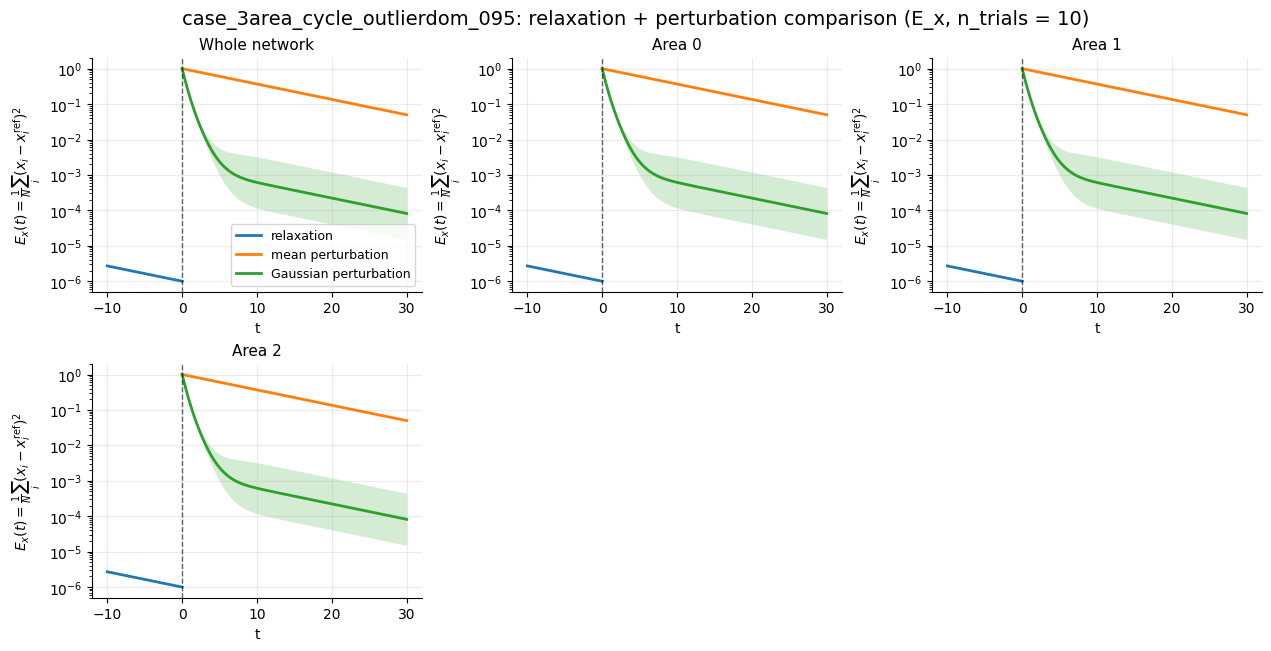

In [6]:
"""
单个case的弛豫加两种扰动对比图
"""
fig = plot_single_case_comparison(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_name="case_3area_cycle_outlierdom_095",
    quantity="E_x",   # or "E_phi"
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("comparision_perturbation_outlierdom_010.png", dpi=300, bbox_inches="tight")
plt.show()

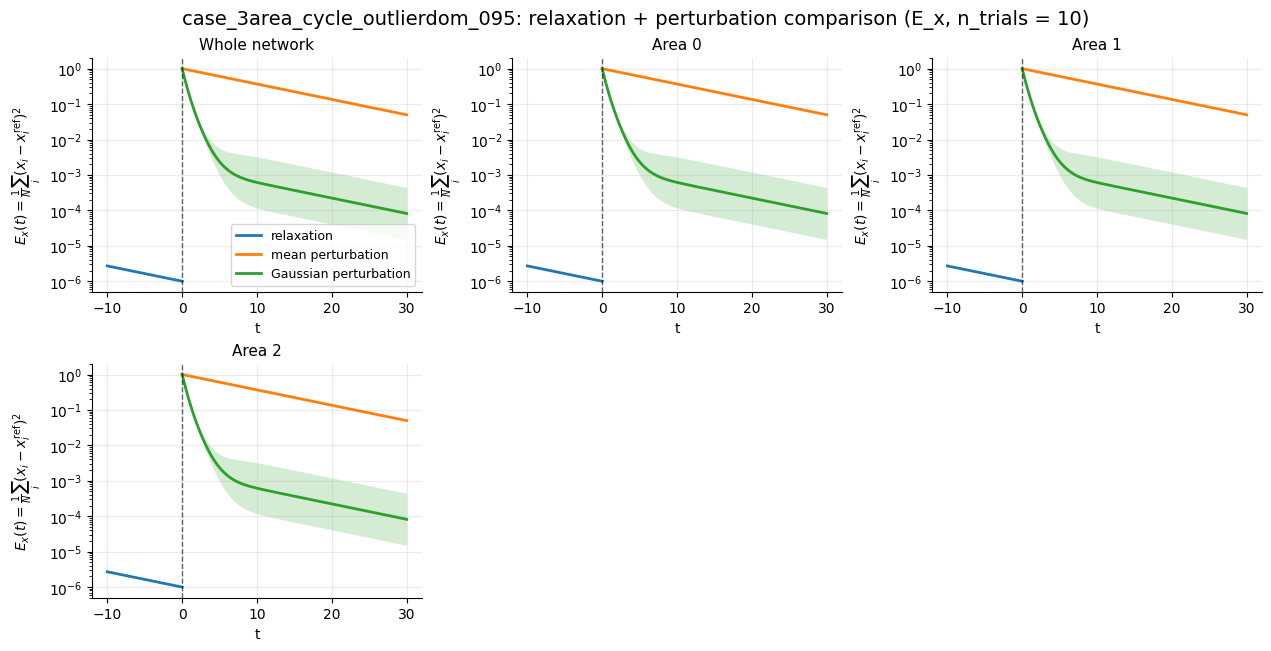

In [7]:
"""
单个case的弛豫加两种扰动对比图
"""
fig = plot_single_case_comparison(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_name="case_3area_cycle_outlierdom_095",
    quantity="E_x",   # or "E_phi"
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("comparision_perturbation_outlierdom_010.png", dpi=300, bbox_inches="tight")
plt.show()

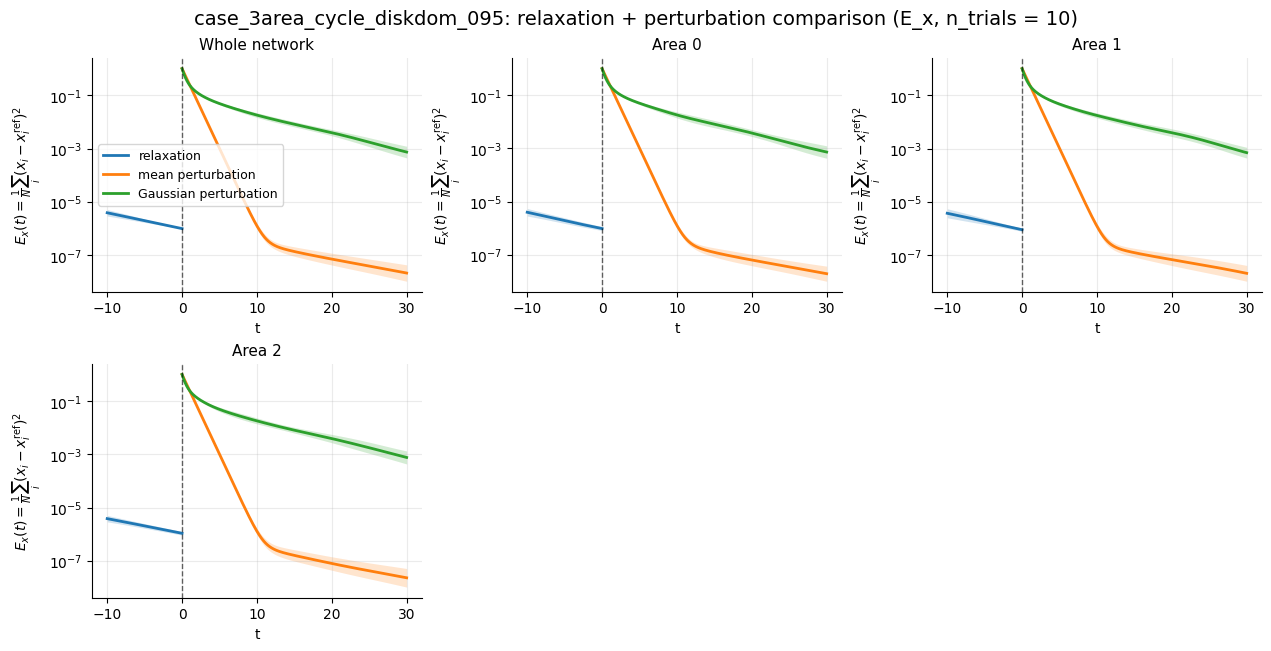

In [8]:
"""
单个case的弛豫加两种扰动对比图
"""
fig = plot_single_case_comparison(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_name="case_3area_cycle_diskdom_095",
    quantity="E_x",   # or "E_phi"
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("comparision_perturbation_outlierdom_010.png", dpi=300, bbox_inches="tight")
plt.show()

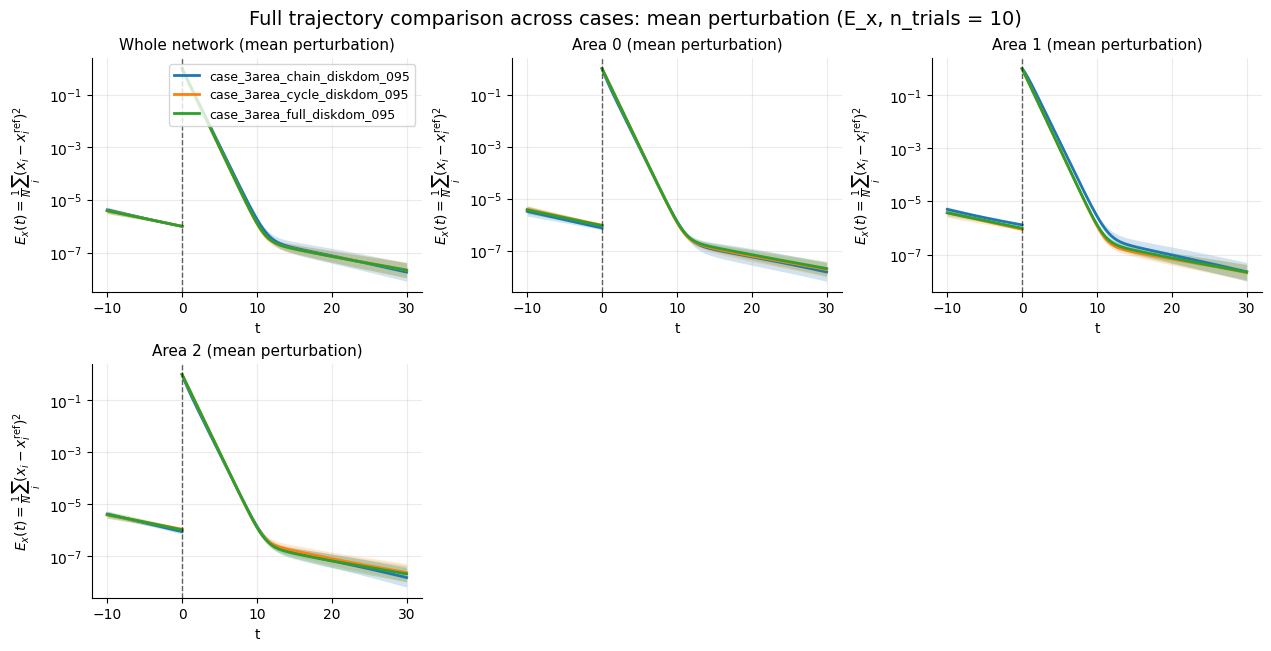

In [9]:
"""
多个cases的均值扰动对比图
"""
fig = plot_multi_case_full_trajectory(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_names=[
        "case_3area_chain_diskdom_095",
        "case_3area_cycle_diskdom_095",
        "case_3area_full_diskdom_095",
        #"case_1_outlierdom_005",
        #"case_2_outlierdom_010",
    ],
    perturbation_name="mean perturbation",
    quantity="E_x",
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("comparision_mean_perturbation_diskdom.png", dpi=300, bbox_inches="tight")
plt.show()

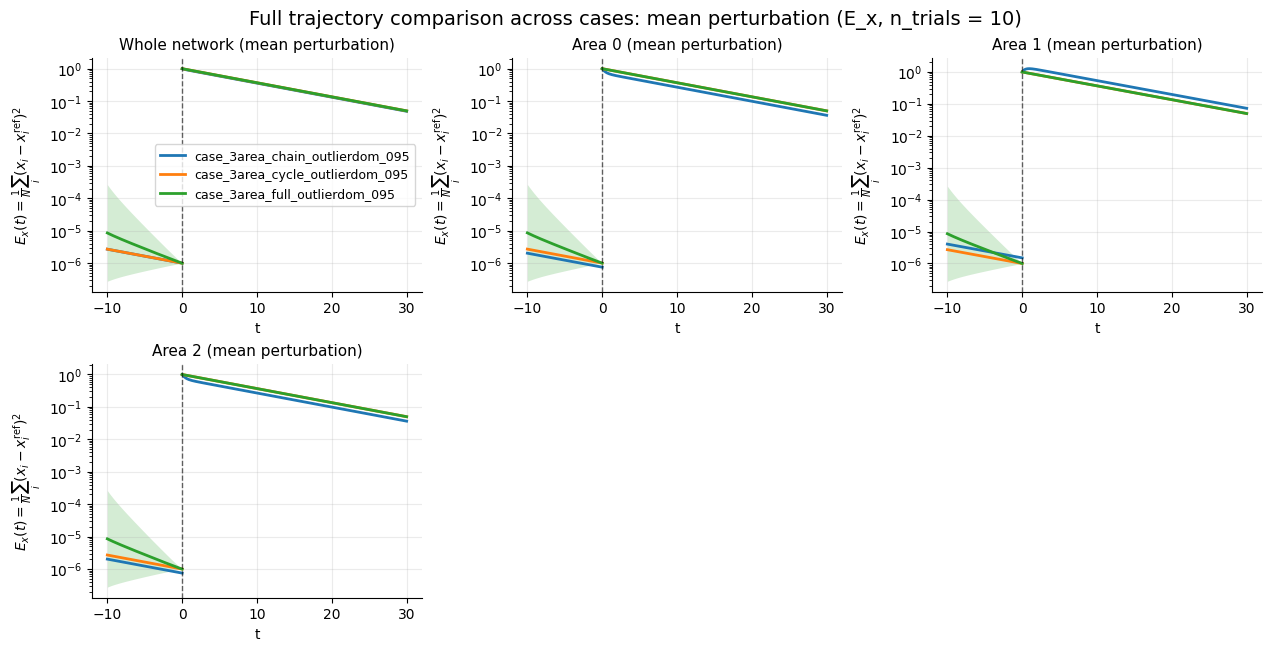

In [ ]:
"""
多个cases的均值扰动对比图
"""
fig = plot_multi_case_full_trajectory(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_names=[
        "case_3area_chain_outlierdom_095",
        "case_3area_cycle_outlierdom_095",
        "case_3area_full_outlierdom_095",
        #"case_1_outlierdom_005",
        #"case_2_outlierdom_010",
    ],
    perturbation_name="mean perturbation",
    quantity="E_x",
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("comparision_mean_perturbation_outlierdom.png", dpi=300, bbox_inches="tight")
plt.show()

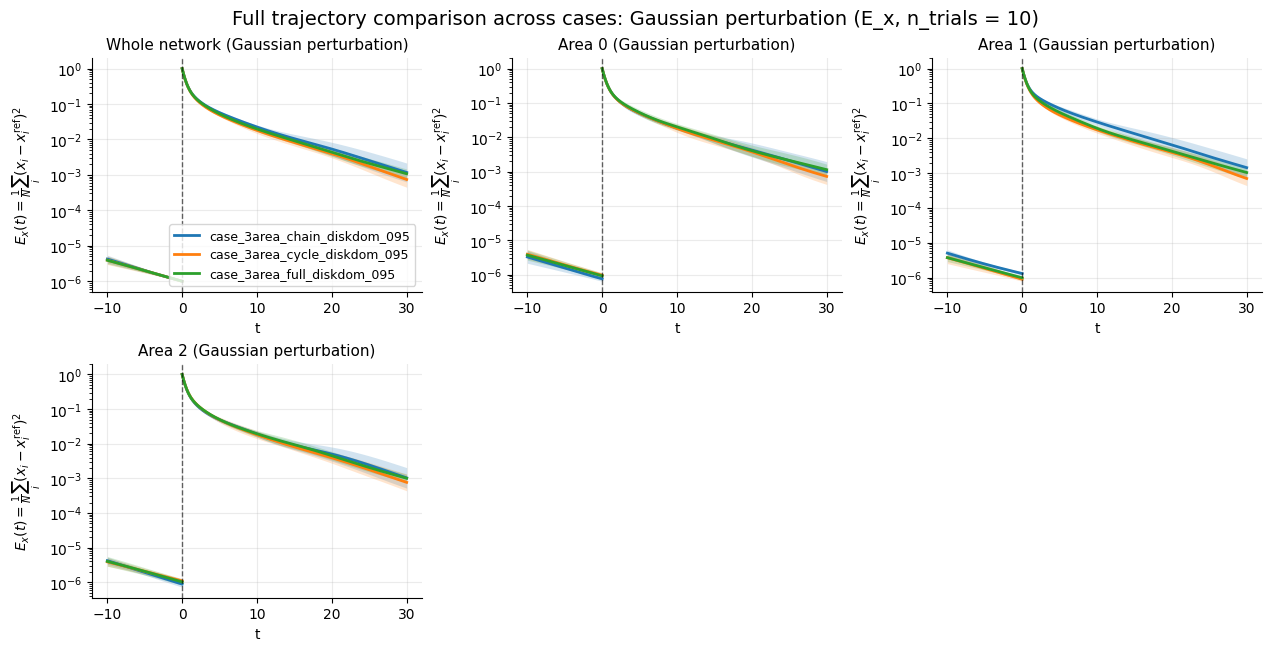

In [12]:
"""
多个cases的高斯扰动对比图
"""
fig = plot_multi_case_full_trajectory(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_names=[
        "case_3area_chain_diskdom_095",
        "case_3area_cycle_diskdom_095",
        "case_3area_full_diskdom_095",
    ],
    perturbation_name="Gaussian perturbation",
    quantity="E_x",
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("comparision_gaussian_perturbation_diskdom.png", dpi=300, bbox_inches="tight")
plt.show()

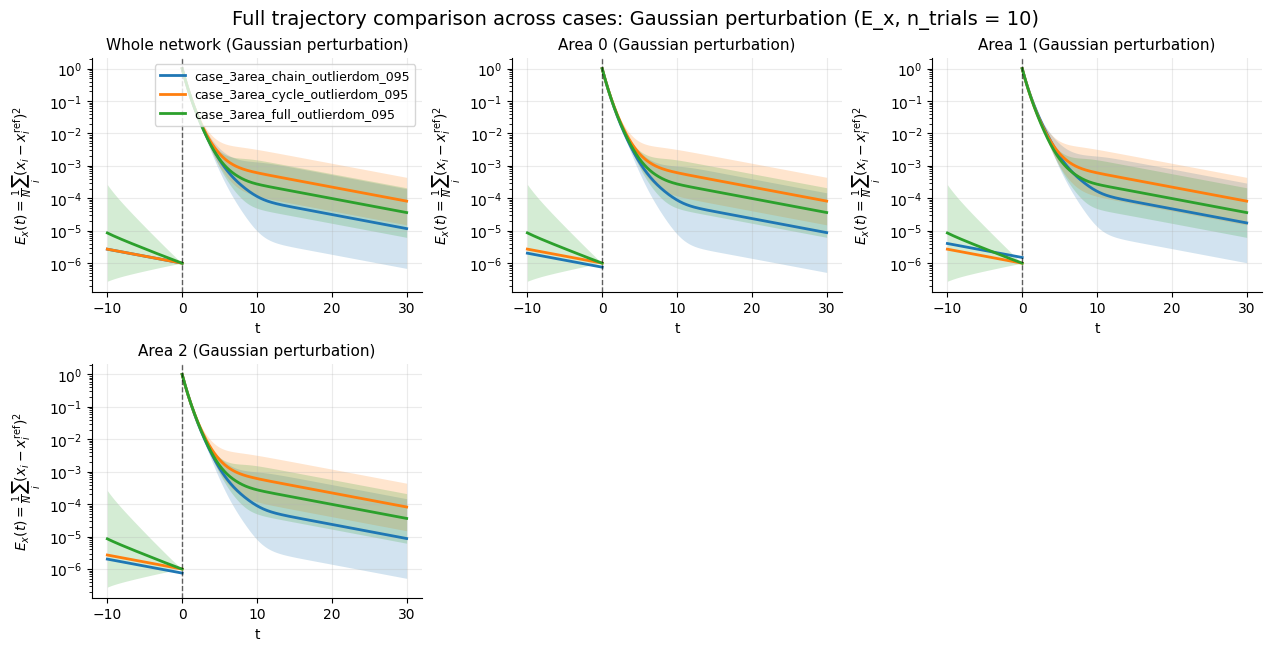

In [13]:
"""
多个cases的高斯扰动对比图
"""
fig = plot_multi_case_full_trajectory(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_names=[
        "case_3area_chain_outlierdom_095",
        "case_3area_cycle_outlierdom_095",
        "case_3area_full_outlierdom_095",
    ],
    perturbation_name="Gaussian perturbation",
    quantity="E_x",
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("comparision_gaussian_perturbation_outlierdom.png", dpi=300, bbox_inches="tight")
plt.show()

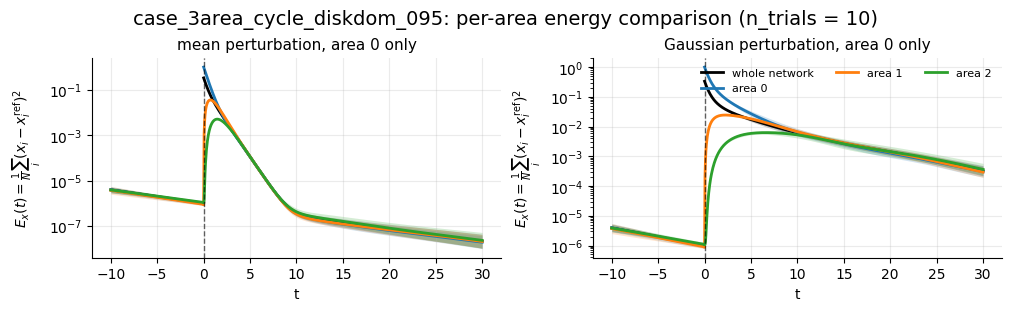

In [13]:
"""
Per-area energy comparison: 2 rows (E_x, E_phi) x N_perturbations cols.
Useful when comparing perturbations with different per-area weights
(e.g. "both areas" vs. "area 0 only").
"""
fig = plot_single_case_energy_area_comparison(
    output_root="Data/perturb/simulation_3area_output_energy_10times_N2000",
    case_name= "case_3area_cycle_diskdom_095",
    perturbation_names=[
        # "mean perturbation",
        # "Gaussian perturbation",
        "mean perturbation, area 0 only",
        "Gaussian perturbation, area 0 only",
    ],
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("3-area_cycle_energy_area_comparison_diskdom_005.png", dpi=300, bbox_inches="tight")
plt.show()

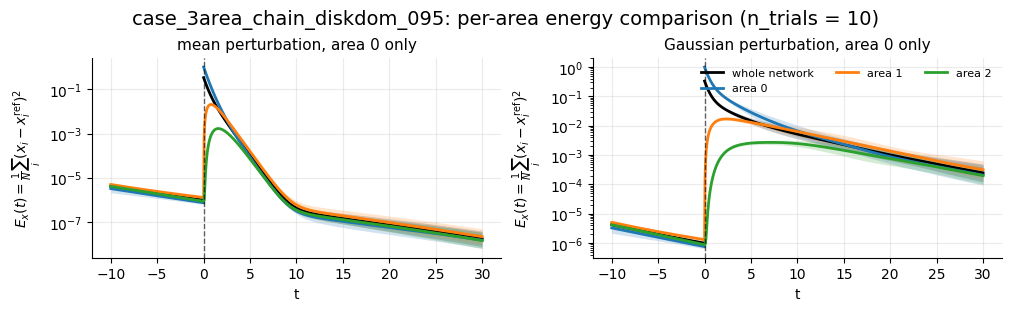

In [14]:
"""
Per-area energy comparison: 2 rows (E_x, E_phi) x N_perturbations cols.
Useful when comparing perturbations with different per-area weights
(e.g. "both areas" vs. "area 0 only").
"""
fig = plot_single_case_energy_area_comparison(
    output_root="Data/perturb/simulation_3area_output_energy_10times_N2000",
    case_name= "case_3area_chain_diskdom_095",
    perturbation_names=[
        # "mean perturbation",
        # "Gaussian perturbation",
        "mean perturbation, area 0 only",
        "Gaussian perturbation, area 0 only",
    ],
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("3-area_chain_energy_area_comparison_diskdom_005.png", dpi=300, bbox_inches="tight")
plt.show()

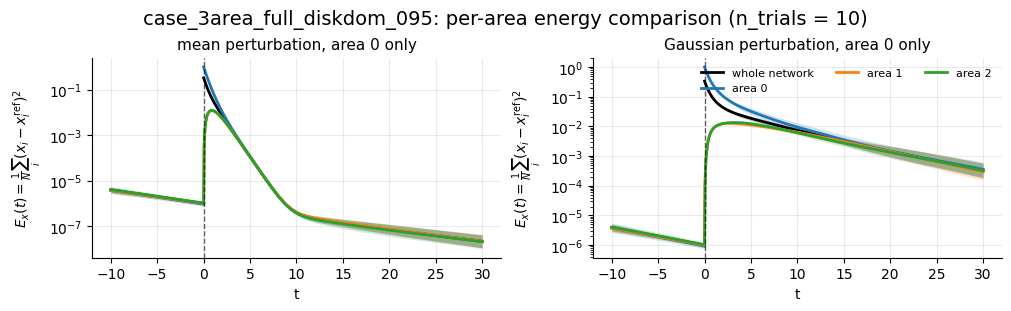

In [15]:
"""
Per-area energy comparison: 2 rows (E_x, E_phi) x N_perturbations cols.
Useful when comparing perturbations with different per-area weights
(e.g. "both areas" vs. "area 0 only").
"""
fig = plot_single_case_energy_area_comparison(
    output_root="Data/perturb/simulation_3area_output_energy_10times_N2000",
    case_name= "case_3area_full_diskdom_095",
    perturbation_names=[
        # "mean perturbation",
        # "Gaussian perturbation",
        "mean perturbation, area 0 only",
        "Gaussian perturbation, area 0 only",
    ],
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("3-area_full_energy_area_comparison_diskdom_005.png", dpi=300, bbox_inches="tight")
plt.show()

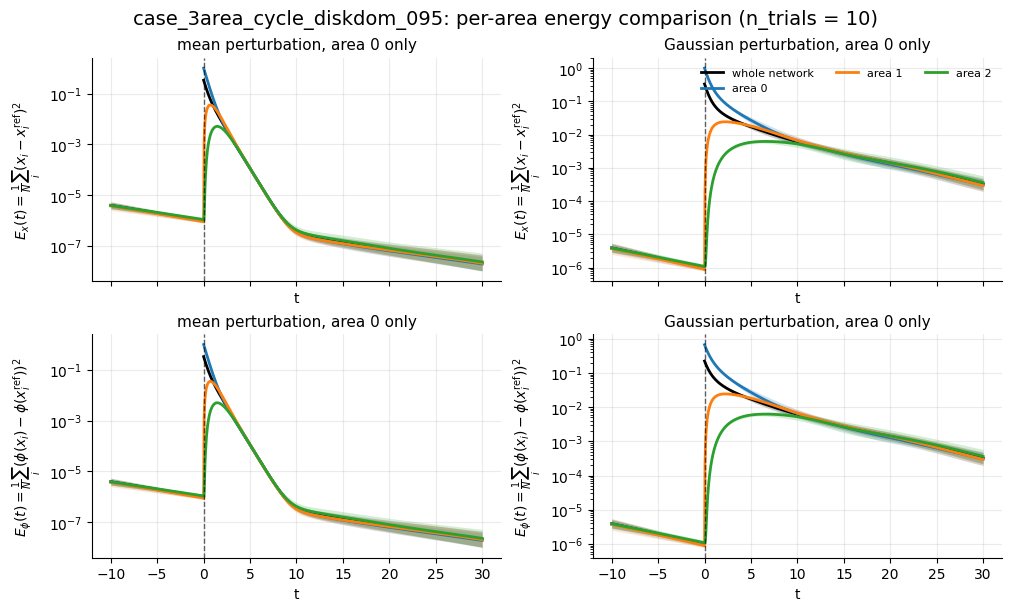

In [ ]:
"""
Per-area energy comparison: 2 rows (E_x, E_phi) x N_perturbations cols.
Useful when comparing perturbations with different per-area weights
(e.g. "both areas" vs. "area 0 only").
"""
fig = plot_single_case_energy_area_comparison(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_name= "case_3area_cycle_diskdom_090",
    perturbation_names=[
        # "mean perturbation",
        # "Gaussian perturbation",
        "mean perturbation, area 0 only",
        "Gaussian perturbation, area 0 only",
    ],
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("energy_area_comparison_outlierdom_005.png", dpi=300, bbox_inches="tight")
plt.show()

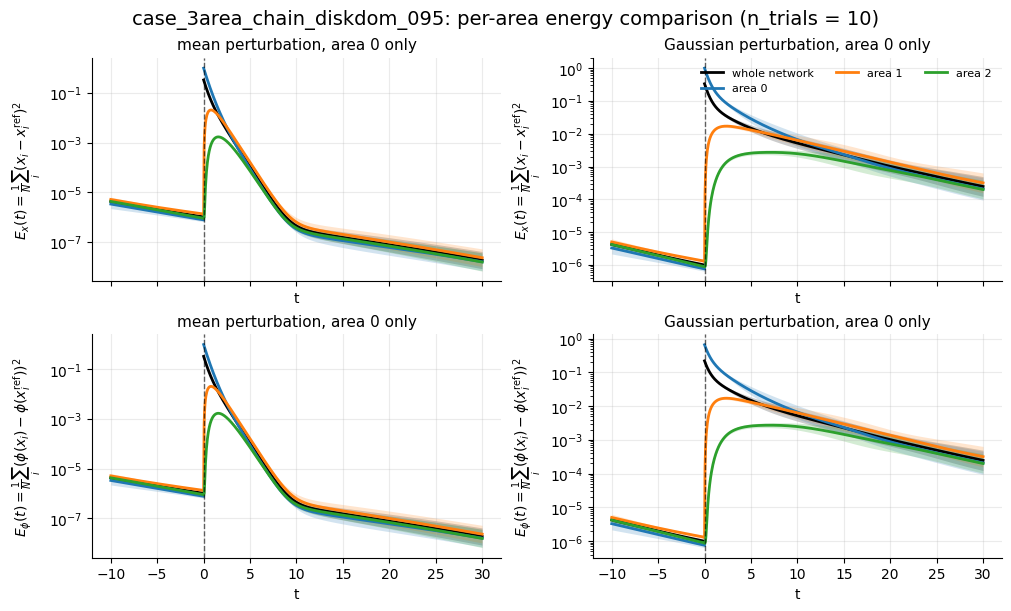

In [ ]:
"""
Per-area energy comparison: 2 rows (E_x, E_phi) x N_perturbations cols.
Useful when comparing perturbations with different per-area weights
(e.g. "both areas" vs. "area 0 only").
"""
fig = plot_single_case_energy_area_comparison(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_name= "case_3area_chain_diskdom_090",
    perturbation_names=[
        # "mean perturbation",
        # "Gaussian perturbation",
        "mean perturbation, area 0 only",
        "Gaussian perturbation, area 0 only",
    ],
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("energy_area_comparison_outlierdom_005.png", dpi=300, bbox_inches="tight")
plt.show()

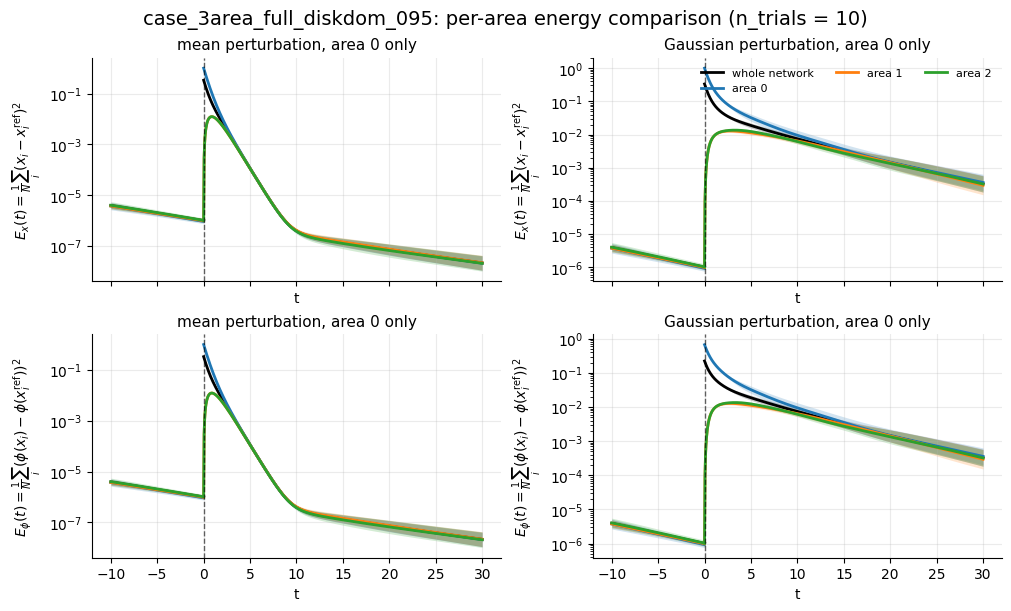

In [22]:
"""
Per-area energy comparison: 2 rows (E_x, E_phi) x N_perturbations cols.
Useful when comparing perturbations with different per-area weights
(e.g. "both areas" vs. "area 0 only").
"""
fig = plot_single_case_energy_area_comparison(
    output_root="simulation_3area_output_energy_10times_N2000",
    case_name= "case_3area_full_diskdom_095",
    perturbation_names=[
        # "mean perturbation",
        # "Gaussian perturbation",
        "mean perturbation, area 0 only",
        "Gaussian perturbation, area 0 only",
    ],
    logy=True,
    post_window=POST_WINDOW,
)
plt.savefig("energy_area_comparison_outlierdom_005.png", dpi=300, bbox_inches="tight")
plt.show()